## TELCO CUSTOMER-CHUN PREDICTION - CLASSIFICATION

##  Importing libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Data

In [3]:
#... This is to connect to Google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#... Importing the data
df =pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Exploratory Data Analysis (EDA) & Visualization



In [5]:
#.. To show the first 10 record of the data
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
#.. This is to show the last 5 records of the data
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
#..df.loc[row_label, column_label]
df.loc[5,['tenure','PhoneService']]

,5
tenure,8
PhoneService,Yes


In [8]:
#..df.loc[row_label, column_label]
df.loc[2:10,'gender']

,gender
2,Male
3,Male
4,Female
5,Female
6,Male
7,Female
8,Female
9,Male
10,Male


In [10]:
#..df.loc[row_label, column_label]
df.loc[3,'tenure']

np.int64(45)

In [9]:
#..df.iloc[row_position, column_position]
df.iloc[2,1]

'Male'

In [11]:
#df.iloc[row_position, column_position]
df.iloc[3,5]

np.int64(45)

In [13]:
#df.iloc[row_position, column_position]
df.iloc[1:10,3:10]

,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity
1,No,No,34,Yes,No,DSL,Yes
2,No,No,2,Yes,No,DSL,Yes
3,No,No,45,No,No phone service,DSL,Yes
4,No,No,2,Yes,No,Fiber optic,No
5,No,No,8,Yes,Yes,Fiber optic,No
6,No,Yes,22,Yes,Yes,Fiber optic,No
7,No,No,10,No,No phone service,DSL,Yes
8,Yes,No,28,Yes,Yes,Fiber optic,No
9,No,Yes,62,Yes,No,DSL,Yes


In [171]:
#.. This is to see all the column headings in the data set
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [14]:
#... To check information about the data
#....To know know if there are missing values
#.... To know the number of row and columns
#... To know the data type we have in the data
#... And the result below show that the columns have equals values which means there are no empty cells
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
#.. This shows the statistical distribution of all the data
#... This gives only the column that are numerical/that have interger data type
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [16]:
#... To Check for Duplicates
#... The result below shows there is no duplicate
df.duplicated().sum()

np.int64(0)

In [17]:
#... This also to check for missing values
#.. And this result below shows we have none
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [18]:
#.. To chech the number of row and column
#.. This result shown we have (7043) rows and (21) columns
df.shape

(7043, 21)

In [19]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [20]:
#.. To check the number of paremeter in some of the columns

label = {'InternetService','Contract','PaymentMethod','Churn'}
for items in label:
  print(df[items].unique())


['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
['DSL' 'Fiber optic' 'No']
['Month-to-month' 'One year' 'Two year']
['No' 'Yes']


## Visualization

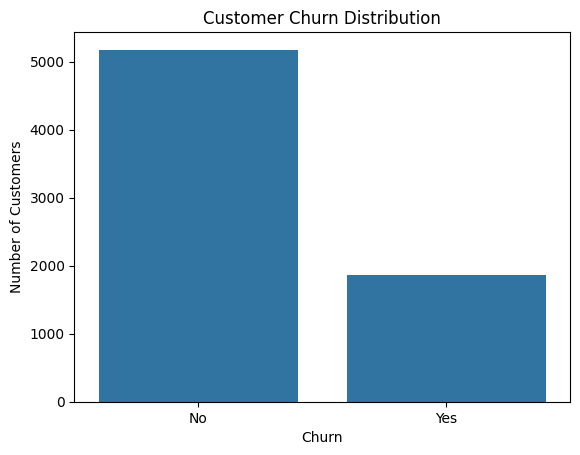

In [21]:
# Plot Churn Distribution Bar Chart
#..This shows that most customers are satisfied enough to continue their subscriptions.
#..Although most customers stay, the churned population is large enough to warrant attention.

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [22]:
#..Numerical Summary
#.Status	Number of Customers	Percentage
#No (Retained)	5,174            	73.46%
#Yes (Churned)	1,869	            26.54%
#.........Total	7,043	            100%

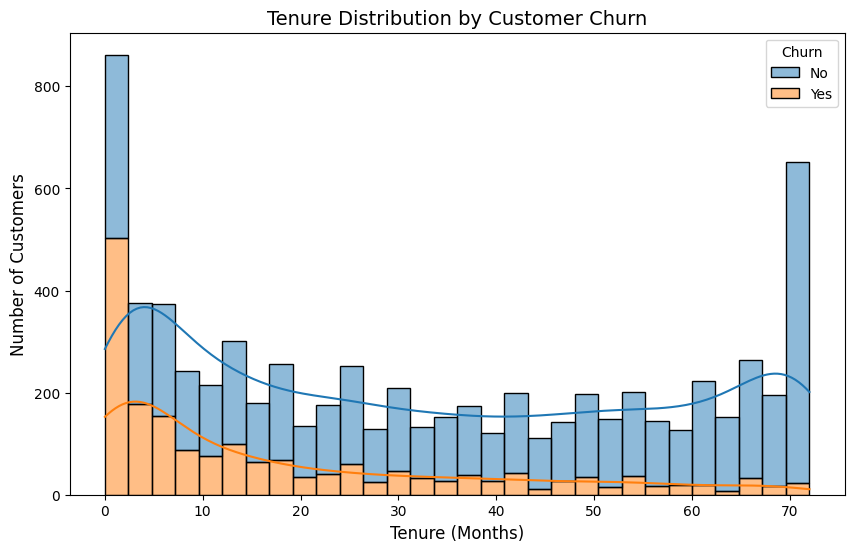

In [23]:
#..Impact of Customer Tenure on Churn Behavior
#The histogram reveals:

#..A large concentration of churned customers at low tenure levels.
#..Retained customers spread across higher tenure ranges.
#..Churn decreases as tenure increases.


def plot_tenure_vs_churn(df):

    plt.figure(figsize=(10,6))

    sns.histplot(
        data=df,
        x='tenure',
        hue='Churn',
        bins=30,
        kde=True,
        multiple='stack'
    )

    plt.title('Tenure Distribution by Customer Churn', fontsize=14)
    plt.xlabel('Tenure (Months)', fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)

    plt.show()

# Call the function
plot_tenure_vs_churn(df)

In [24]:
def plot_tenure_vs_churn(df):

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x='Churn',
        y='tenure',
        data=df
    )

    plt.title('Impact of Customer Tenure on Churn Behavior')
    plt.xlabel('Churn Status (0 = Stayed, 1 = Churned)')
    plt.ylabel('Customer Tenure (Months)')
    plot_tenure_vs_churn(df)

    plt.show()

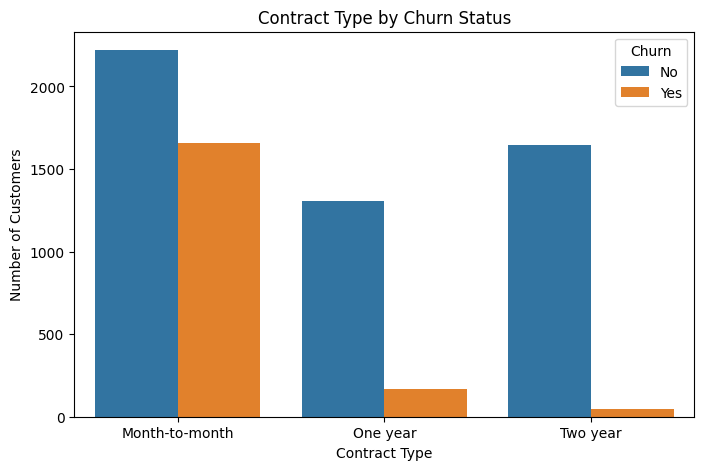

In [25]:
#..This chart provides a clearer view of churn rates by contract type.
#..In the actual chart:

#..Blue bars represent Non-Churned Customers (No).
#..Orange bars represent Churned Customers (Yes).
#..Each contract category contains two bars.

plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title('Contract Type by Churn Status')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

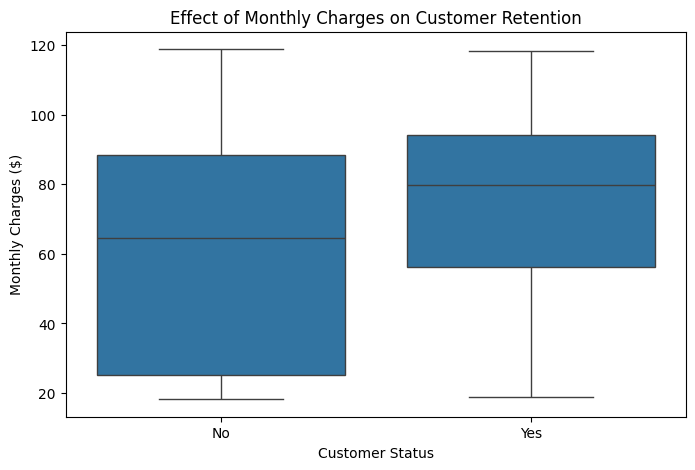

In [26]:
#.. This shows the effect of monthly charges on customer retention
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title('Effect of Monthly Charges on Customer Retention')
plt.xlabel('Customer Status')
plt.ylabel('Monthly Charges ($)')

plt.show()

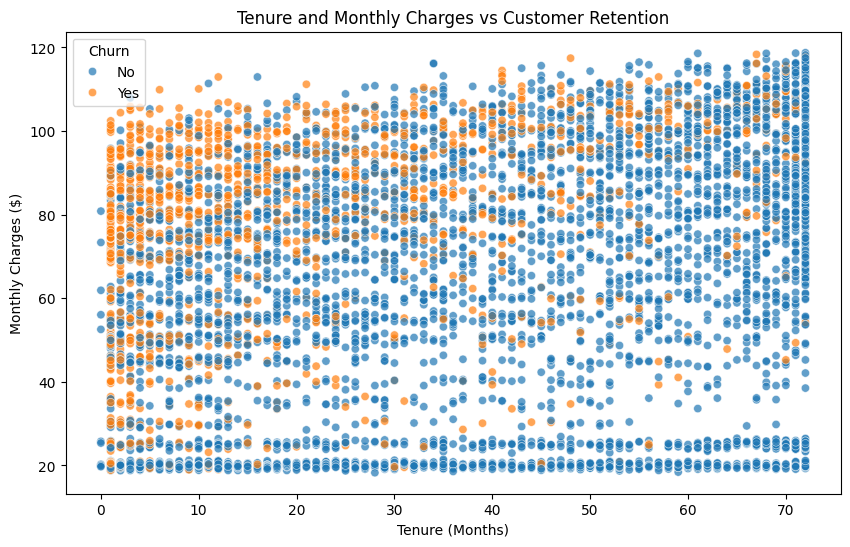

In [28]:
#..The scatter plot reveals the following:

#..Churned customers cluster around low tenure and high monthly charges.
#..Retained customers cluster around high tenure and moderate charges.
#..Customers with both low tenure and expensive plans are at the highest risk of churn.

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    data=df,
    alpha=0.7
)

plt.title('Tenure and Monthly Charges vs Customer Retention')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges ($)')

plt.show()

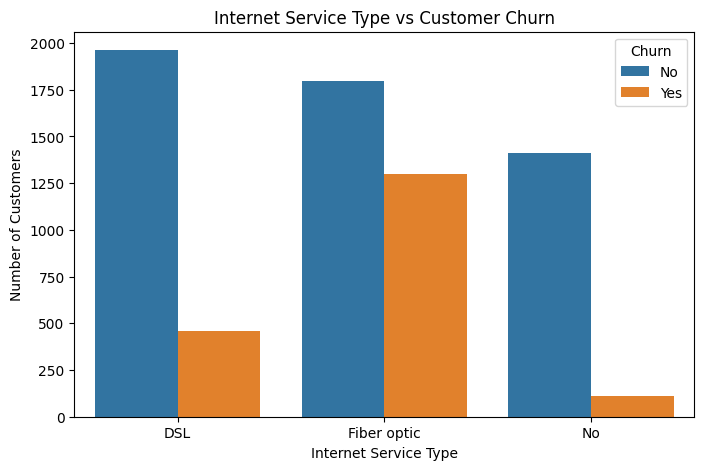

In [29]:
#..................Internet Service Type vs Customer Churn

# This result shows that Customers using Fiber Optic Internet are considerably more likely to churn than DSL users.
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title('Internet Service Type vs Customer Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')

plt.show()

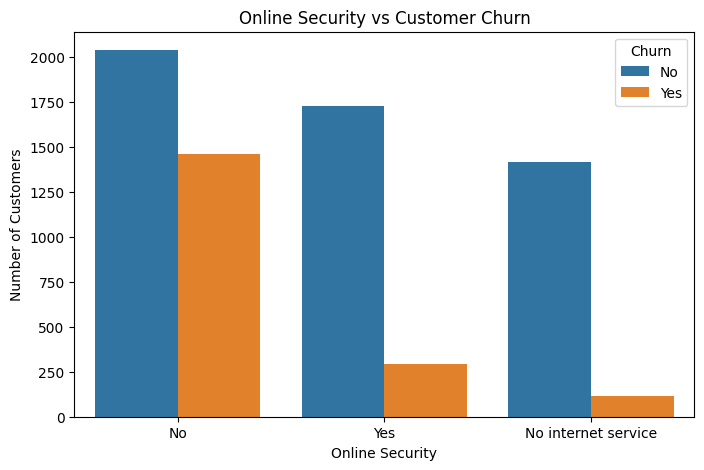

In [30]:
#..Customers without online security services are much more likely to leave
plt.figure(figsize=(8,5))

sns.countplot(
    x='OnlineSecurity',
    hue='Churn',
    data=df
)

plt.title('Online Security vs Customer Churn')
plt.xlabel('Online Security')
plt.ylabel('Number of Customers')

plt.show()

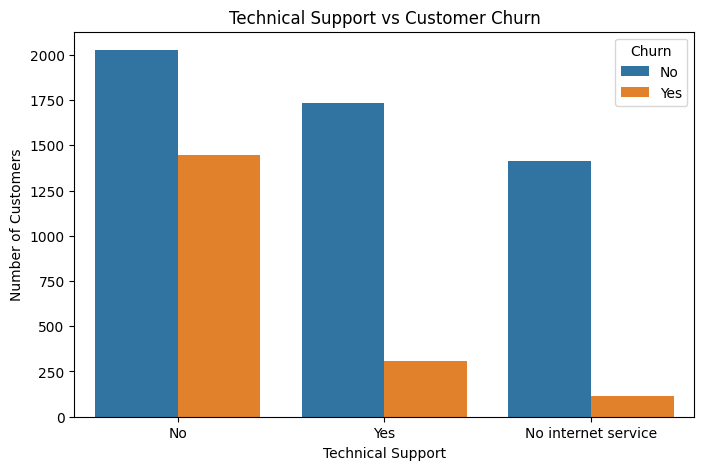

In [31]:
#..........Tech Support vs Churn.......
#... Customer that do not have/subscribe to tech support:
#...Higher number of churned customers
#...Higher churn risk

#.... Customer that have/subscribe tech support:
#..Lower number of churned customers
#..Better customer retention

plt.figure(figsize=(8,5))

sns.countplot(
    x='TechSupport',
    hue='Churn',
    data=df
)

plt.title('Technical Support vs Customer Churn')
plt.xlabel('Technical Support')
plt.ylabel('Number of Customers')

plt.show()

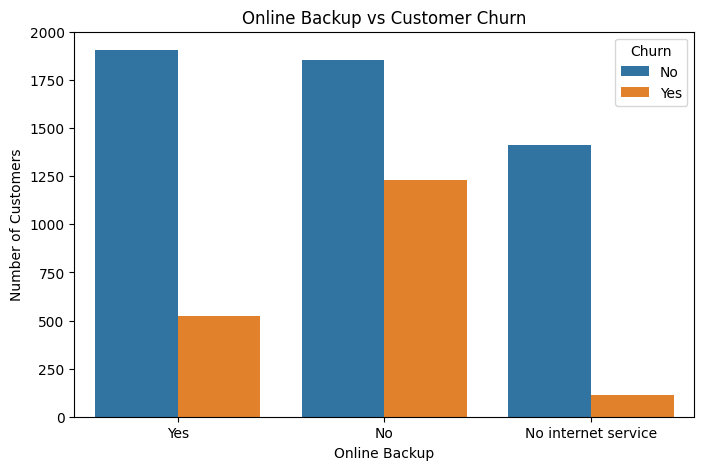

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='OnlineBackup',
    hue='Churn',
    data=df
)

plt.title('Online Backup vs Customer Churn')
plt.xlabel('Online Backup')
plt.ylabel('Number of Customers')

plt.show()

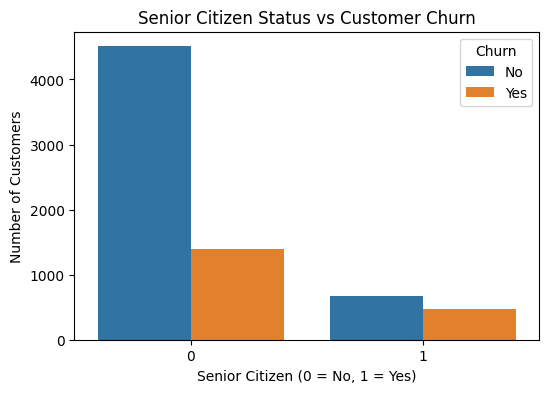

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.title('Senior Citizen Status vs Customer Churn')
plt.xlabel('Senior Citizen (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

plt.show()

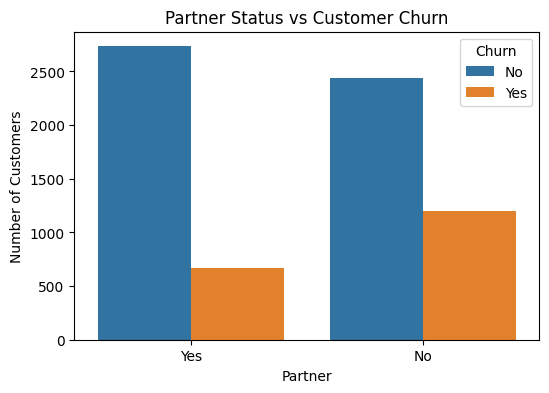

In [34]:
#..Customers with partners are generally more stable and less likely to switch providers.
plt.figure(figsize=(6,4))

sns.countplot(
    x='Partner',
    hue='Churn',
    data=df
)

plt.title('Partner Status vs Customer Churn')
plt.xlabel('Partner')
plt.ylabel('Number of Customers')

plt.show()

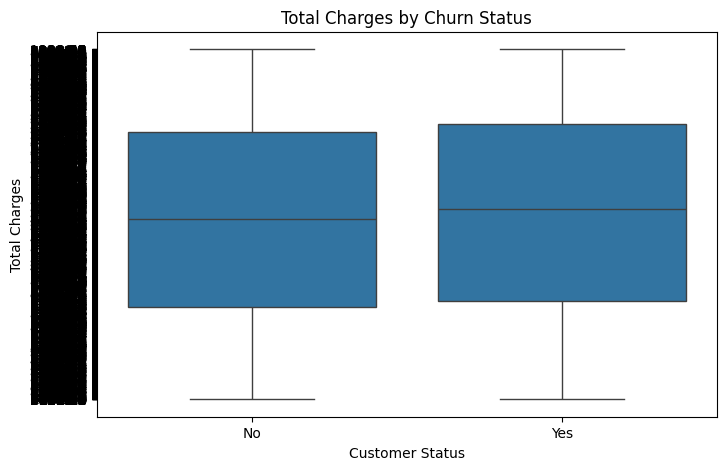

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)

plt.title('Total Charges by Churn Status')
plt.xlabel('Customer Status')
plt.ylabel('Total Charges')

plt.show()

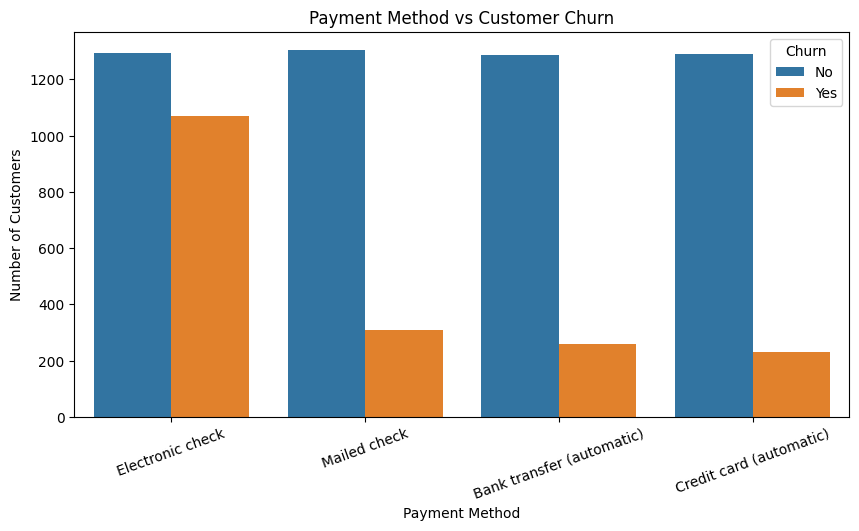

In [36]:
#..Customers using electronic checks are considerably more likely to churn
plt.figure(figsize=(10,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title('Payment Method vs Customer Churn')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')

plt.xticks(rotation=20)

plt.show()

In [37]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [49]:
df.drop(['customerID','PhoneService','MultipleLines','gender'], axis=1, inplace=True)

In [50]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilyCustomer,CustomerLifetimeValue
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,29.85
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,1936.30
2,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,107.70
3,0,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,1903.50
4,0,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,141.40


In [51]:
df['TotalCharges'].dtype

dtype('float64')

In [55]:
#.. This helps to change the data type from object to float
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [56]:
df.head(5)

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilyCustomer,CustomerLifetimeValue
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,29.85
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,1936.30
2,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,107.70
3,0,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,1903.50
4,0,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,141.40


In [53]:
df['TotalCharges'].dtype

dtype('float64')

In [57]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [59]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [60]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SeniorCitizen          7043 non-null   int64  
 1   Partner                7043 non-null   object 
 2   Dependents             7043 non-null   object 
 3   tenure                 7043 non-null   int64  
 4   InternetService        7043 non-null   object 
 5   OnlineSecurity         7043 non-null   object 
 6   OnlineBackup           7043 non-null   object 
 7   DeviceProtection       7043 non-null   object 
 8   TechSupport            7043 non-null   object 
 9   StreamingTV            7043 non-null   object 
 10  StreamingMovies        7043 non-null   object 
 11  Contract               7043 non-null   object 
 12  PaperlessBilling       7043 non-null   object 
 13  PaymentMethod          7043 non-null   object 
 14  MonthlyCharges         7043 non-null   float64
 15  Tota

#Feature Engineering

In [62]:
#...This feature is useful because it captures whether a customer has family ties that may influence churn behavior.
df['FamilyCustomer'] = (
    (df['Partner']=='Yes') |
    (df['Dependents']=='Yes')
).astype(int)

In [63]:
#..It estimates the total revenue generated by a customer during their time with the company.
#...where
#...MonthlyCharges = Amount paid by the customer each month.
#...Tenure = Number of months the customer has stayed with the company.
df['CustomerLifetimeValue'] = (
    df['MonthlyCharges'] * df['tenure']
)

In [64]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilyCustomer,CustomerLifetimeValue
0,0,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,29.85
1,0,No,No,34,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,1936.30
2,0,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,107.70
3,0,No,No,45,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,1903.50
4,0,No,No,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,141.40


In [65]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'FamilyCustomer', 'CustomerLifetimeValue'],
      dtype='object')

In [66]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0
    })

/tmp/ipykernel_4534/250005563.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [67]:
#....These are service-related features that indicate whether a customer subscribes to a particular service.
# Service-related columns available in the dataset
services = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Convert Yes/No values to 1/0 and create TotalServices column
#.. means changing them from string data type to interger
df['TotalServices'] = (
    df[services]
    .replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0
    })
    .astype(int)
    .sum(axis=1)
)

# Preview result
df[['TotalServices']].head()

,TotalServices
0,1
1,2
2,2
3,3
4,0


In [69]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilyCustomer,CustomerLifetimeValue,TotalServices
0,0,Yes,No,1,DSL,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,29.85,1
1,0,No,No,34,DSL,1,0,1,0,0,0,One year,No,Mailed check,56.95,1889.50,No,0,1936.30,2
2,0,No,No,2,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,107.70,2
3,0,No,No,45,DSL,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,1903.50,3
4,0,No,No,2,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,141.40,0


#Encoding

In [70]:
df.head(5)

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilyCustomer,CustomerLifetimeValue,TotalServices
0,0,Yes,No,1,DSL,0,1,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,29.85,1
1,0,No,No,34,DSL,1,0,1,0,0,0,One year,No,Mailed check,56.95,1889.50,No,0,1936.30,2
2,0,No,No,2,DSL,1,1,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0,107.70,2
3,0,No,No,45,DSL,1,0,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,1903.50,3
4,0,No,No,2,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0,141.40,0


In [71]:
df.select_dtypes(include='object').columns

Index(['Partner', 'Dependents', 'InternetService', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [72]:
#..It loops through every column in the dataframe and checks whether the column contains only the values:'yes' and 'No' and list them out
for col in df.columns:
    unique_vals = set(df[col].dropna().unique())

    if unique_vals == {'Yes', 'No'}:
        print(col)

Partner
Dependents
PaperlessBilling
Churn


In [73]:
service_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in service_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0
    })

In [74]:
yes_no_cols = [
    'Partner',
    'Dependents',
    'PaperlessBilling',
    'Churn'
]

for col in yes_no_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0
    })

/tmp/ipykernel_4534/1131859412.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [75]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,FamilyCustomer,CustomerLifetimeValue,TotalServices
0,0,1,0,1,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0,1,29.85,1
1,0,0,0,34,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0,0,1936.30,2
2,0,0,0,2,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1,0,107.70,2
3,0,0,0,45,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,0,1903.50,3
4,0,0,0,2,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,0,141.40,0


In [119]:
#..One-Hot Encoding on the remaining categorical columns in the dataset as shown below:

#...internet service;
#...0,0 = DSL
#...1,0 = Fiber optic
#...0,1 = No Internet Service

#...contract;
#..0,0 = Month-to-month
#..1,0 = One year
#..0,1 = Two year

#...0,0,0 = Bank transfer (automatic)
#...1,0,0 = Credit Card (Automatic)
#...0,1,0 = Electronic Check
#...0,0,1 = Mailed Check

In [76]:
categorical_cols = [
    'InternetService',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [77]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,...,FamilyCustomer,CustomerLifetimeValue,TotalServices,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,0,0,0,0,...,1,29.85,1,False,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,0,0,...,0,1936.30,2,False,False,True,False,False,False,True
2,0,0,0,2,1,1,0,0,0,0,...,0,107.70,2,False,False,False,False,False,False,True
3,0,0,0,45,1,0,1,1,0,0,...,0,1903.50,3,False,False,True,False,False,False,False
4,0,0,0,2,0,0,0,0,0,0,...,0,141.40,0,True,False,False,False,False,True,False


In [78]:
#... this helps to covert Boolean columns to integer
#.... True= 1
#.....False= 0
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [79]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,...,FamilyCustomer,CustomerLifetimeValue,TotalServices,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,0,0,0,0,...,1,29.85,1,0,0,0,0,0,1,0
1,0,0,0,34,1,0,1,0,0,0,...,0,1936.30,2,0,0,1,0,0,0,1
2,0,0,0,2,1,1,0,0,0,0,...,0,107.70,2,0,0,0,0,0,0,1
3,0,0,0,45,1,0,1,1,0,0,...,0,1903.50,3,0,0,1,0,0,0,0
4,0,0,0,2,0,0,0,0,0,0,...,0,141.40,0,1,0,0,0,0,1,0


In [80]:
#.. This is to re-check the data set to be sure its only interger and float as the models only recognise the 2 data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   OnlineSecurity                         7043 non-null   int64  
 5   OnlineBackup                           7043 non-null   int64  
 6   DeviceProtection                       7043 non-null   int64  
 7   TechSupport                            7043 non-null   int64  
 8   StreamingTV                            7043 non-null   int64  
 9   StreamingMovies                        7043 non-null   int64  
 10  PaperlessBilling                       7043 non-null   int64  
 11  Mont

In [81]:
#...seperating the features and target
#..Creates the feature matrix by selecting all columns except Churn.
#..These are the variables the model uses to learn patterns.
#...Creates the target variable containing what we want to predict.
#... feature= x, target= y

X = df.drop('Churn', axis=1)

y = df['Churn']

In [82]:
print(X.shape)
print(y.shape)

(7043, 23)
(7043,)


In [83]:
#.... This shows the columns in our feature which is x without the target column 'Churn'
print(X.columns)

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'FamilyCustomer', 'CustomerLifetimeValue', 'TotalServices',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [84]:
#... To check y distribution
#...5,174 customers stayed.
#...1,869 customers churned.
y.value_counts()

,count
Churn,
0,5174
1,1869


In [85]:
#...This code performs the Train-Test Split, which is the process of dividing your dataset into two parts:
#...test_size=0.2 means the testing set is 20%
#... random_state=42 help you get the same split every time you run the code.
#.. it help with fair model comparison
#.. stratify=y ensures both training and testing datasets maintain the same class proportions.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
#....Scaling Numerical Features
#..This code performs Feature Scaling (Standardization) on the continuous numerical features before training the Logistic Regression model.
#.we scale because the numerical features have very different ranges
## without scaling,The model may give too much importance to larger numbers simply because of their magnitude.
scale_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'CustomerLifetimeValue'
]

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(
    X_train[scale_cols]
)

X_test[scale_cols] = scaler.transform(
    X_test[scale_cols]
)

In [88]:
check_cols = [
    'Partner',
    'Dependents',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Churn'
]

df[check_cols].isnull().sum()

,0
Partner,0
Dependents,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0
StreamingMovies,0
PaperlessBilling,0
Churn,0


In [90]:
check_cols = [
    'Partner',
    'Dependents',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Churn'
]

df[check_cols].isnull().sum()

,0
Partner,0
Dependents,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0
TechSupport,0
StreamingTV,0
StreamingMovies,0
PaperlessBilling,0
Churn,0


In [89]:
df.isnull().sum().sum()

np.int64(0)

In [137]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'FamilyCustomer', 'CustomerLifetimeValue', 'TotalServices',
       'InternetService_Fiber optic', 'InternetService_No',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [91]:
df['Churn'].unique()

array([0, 1])

In [92]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

,0


In [238]:
# Categorical columns → fill with mode
#..This code is used to fill missing values (NaN) in categorical columns of X_train.
cat_cols = X_train.select_dtypes(include=['object']).columns

for col in cat_cols:
    X_train[col] = X_train[col].fillna(X_train[col].mode()[0])


In [239]:
# Do the same for X_test
X_test[num_cols] = X_test[num_cols].fillna(X_test[num_cols].median())

In [145]:
for col in cat_cols:
    X_test[col] = X_test[col].fillna(X_test[col].mode()[0])

In [95]:
# Train model again
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [96]:
#..Make prediction
y_pred = lr.predict(X_test)

In [97]:
#....Evaluate the model
#....Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7963094393186657


In [98]:
#.....Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [99]:
#..... Confusion matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[922 113]
 [174 200]]


In [100]:
#.....ROC-AUC Score

from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.8412152212663722


In [101]:
#.....Compare With Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

Random Forest Accuracy: 0.7842441447835344


Project Workflow Summary

✅ Data Loading

✅ Data Cleaning

✅ Missing Value Treatment

✅ Feature Engineering

✅ Encoding

✅ Feature Scaling

✅ Train-Test Split

✅ Logistic Regression Training

🔲 Model Evaluation

🔲 Random Forest Comparison

🔲 Feature Importance Analysis

🔲 Churn Prediction

In [102]:
#...Compare Actual vs Predicted Values
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
437,0,0
2280,0,1
2235,0,0
4460,0,0
3761,0,0
5748,0,1
3568,0,1
2976,0,0
5928,0,0
1639,1,0


In [103]:
#.... create a new customer
customer_data = {

    'SeniorCitizen': 0,
    'Partner': 1,
    'Dependents': 0,
    'tenure': 5,
    'OnlineSecurity': 0,
    'OnlineBackup': 1,
    'DeviceProtection': 0,
    'TechSupport': 0,
    'StreamingTV': 1,
    'StreamingMovies': 1,
    'PaperlessBilling': 1,
    'MonthlyCharges': 85.50,
    'TotalCharges': 427.50,
    'FamilyCustomer': 1,
    'CustomerLifetimeValue': 427.50,
    'TotalServices': 3,
    'InternetService_Fiber optic': 1,
    'InternetService_No': 0,
    'Contract_One year': 0,
    'Contract_Two year': 0,
    'PaymentMethod_Credit card (automatic)': 0,
    'PaymentMethod_Electronic check': 1,
    'PaymentMethod_Mailed check': 0
}

In [107]:
new_customer = pd.DataFrame([customer_data])

In [108]:
#....1 = Customer will churn
#....0 = Customer will stay

prediction = lr.predict(new_customer)

print(prediction)

[1]


In [106]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.7963094393186657

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[922 113]
 [174 200]]
